<a href="https://colab.research.google.com/github/plopezmp/AmI/blob/main/c2021_NoSupervisado_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Preambulo:** 

Montamos nuestro `Google Drive` donde tenemos guardado el notebook de Python.

In [ ]:
import os
os.chdir('/content/drive/My Drive/Colab Notebooks/')
%pwd

In [1]:
!python --version

Python 3.7.10


**Este notebook es un ejemplo de aplicación del algoritmo PCA para *reducir dimensionalidad de un problema*.**

***

# Ejemplo de aplicación de PCA

In [11]:
import pandas as pd
import numpy as np
import random as rd
from sklearn.decomposition import PCA # este PCA es el más usado
from sklearn import preprocessing # el paso 1: escalado y normalización
import matplotlib.pyplot as plt

## Generamos datos para el ejemplo

Los datos de este ejemplo están en un pandas DataFrame de nombre *data*.
Las columnas (features) son muestras individuales, por ejemplo, podemos pensar que son células.
Las filas del DataFrame son medidas (muestras) tomadas de todas las muestras (células).
(estos datos son para el ejemplo, y son irreales...)

In [12]:
genes = ['gen' + str(i) for i in range(1,101)]

Hemos creado 100 genes, gen1, gen2,...,gen100.

Ahora, creamos muestras de esos genes, 5 muestras tipo 'w' y 5 tipo 'k'.

In [16]:
w = ['w' + str(i) for i in range(1,6)]
k = ['k' + str(i) for i in range(1,6)]

In [17]:
data = pd.DataFrame(columns=[*w, *k], index=genes)
# el asterçisco de *w y *k es para que haga el join de w y t en la misma lista
# y no cree una lista de listas.
# Los index del pandas DataFrame son los nombres de los genes, gen1 a gen100.

los datos que generamos VA Poisson lo hacemos variando el valor de $\lambda$:

In [18]:
for gen in data.index:
    data.loc[gen,'w1':'w5'] = np.random.poisson(lam=rd.randrange(10,1000), size=5)
    data.loc[gen,'k1':'k5'] = np.random.poisson(lam=rd.randrange(10,1000), size=5)

In [19]:
print(data.head()) 
# head() saca sólo las 5 primeras filas

       w1   w2   w3   w4   w5   k1   k2   k3   k4   k5
gen1   29   26   15   29   26  617  609  591  619  610
gen2  220  222  251  217  232  550  575  492  552  524
gen3  334  365  391  357  360  184  156  180  191  202
gen4  323  366  353  320  352  867  832  913  810  865
gen5  675  670  712  683  674  211  201  229  216  226


In [20]:
print(data.shape)

(100, 10)


Comprobamos con `shape` que tenemos 100 genes y de cada uno 10 muestras.

## Aplicamos PCA a los datos

### Preprocesado

Centramos y escalamos los datos. Tras hacerlo, los datos tendrán $\mu=0$ y $s=1$.

In [22]:
scaled_data = preprocessing.scale(data.T)
# Nota: pasamos 'data' transpuesta porque la función requiere que se pasen 
# muestras en filas y no en columnas.
pca = PCA() # creamos un objeto PCA
pca.fit(scaled_data) # hacemos el fit con nuestros datos
# en el fit es donde hacemos toda la matemática. Se calculan las variaciones 
# que cada componente principal representa.
# Finalmente, computo las nuevas coordenadas en las dimensiones reducidas con PCA,
# es decir las proyecciones en las componentes principales.
pca_data = pca.transform(scaled_data) 

En la celda de arriba, una forma alternativa de hacer escalado es usar:

`StandardScaler().fit_transform(data.T)`
esta forma se utiliza con frecuencia en `scikit-learn`.

### Mostramos los datos 

Hacemos una figura de la varianza de los componentes principales (eigenvalues). En estadística esta figura se llama *scree plot*. 

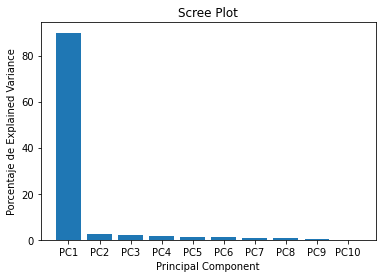

In [23]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
# "per_var" es la varianza de los datos que representa cada componente principal
# Creamos las etiquetas del eje X.
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]
 
plt.bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
plt.ylabel('Porcentaje de Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.show()

Un porcentaje alto de *explained variance* indica una mayor relación o asociación y que nos permite hacer mejores predicciones. Por lo tanto,  si selecciono como nuevas *features* a PC1 y PC2, con esas dos dimensiones nada más voy a tener bien representados mis datos porque son los que recogen mejor (sobre todo PC1) mis datos. 
Proyectando sobre PC1 el *Error de Proyección* va a ser muy pequeño.

Mostramos ahora la *proyección* en las nuevas coordenadas (PC1 y PC2) de las muestras.

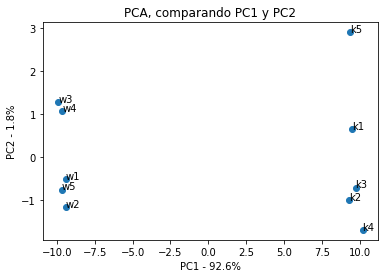

In [16]:
pca_df = pd.DataFrame(pca_data, index=[*w, *k], columns=labels)
 
plt.scatter(pca_df.PC1, pca_df.PC2)
plt.title('PCA, comparando PC1 y PC2')
plt.xlabel('PC1 - {0}%'.format(per_var[0]))
plt.ylabel('PC2 - {0}%'.format(per_var[1]))
 
for sample in pca_df.index:
    plt.annotate(sample, (pca_df.PC1.loc[sample], pca_df.PC2.loc[sample]))
 
plt.show()

En esta figura vemos que las muestras (propiedades) w1 a w5 forman un *cluster* lo que sugiere que están correladas, y lo mismo sucede con el *cluster* formado por k1 a k5. 

Entre los dos grupos existen una separación lo que significa que las muestras w's y k's son *diferentes*. 

***

Ahora miramos qué muestras de gen, **qué genes** son los que tienen mayor influencia sobre PC1 y que provocan la separación entre los *clusters*.

Creamos un pandas series para guardar el `score` de los genes en el componente PC1.



In [24]:
loading_scores = pd.Series(pca.components_[0], index=genes)

El valor de `pca.components_[0]` son los valores de PC1 (su índice es 0 dentro de `pca.components`).

A continuación,  ordeno esos valore en función de su magnitud (valor absoluto). 

In [25]:
sorted_loading_scores = loading_scores.abs().sort_values(ascending=False)

Los valores de *loading_score* son las covarianzas/correlaciones entre las features originales y los componentes principales.

Obtengo los nombres de los genes de los 10 índices más altos (en valor absoluto), y hacemos un *print*.

In [27]:
top_10_genes = sorted_loading_scores[0:10].index.values
print(loading_scores[top_10_genes]) 

gen60   -0.105400
gen87   -0.105385
gen26    0.105383
gen98   -0.105383
gen1    -0.105371
gen90   -0.105344
gen66   -0.105343
gen77    0.105336
gen15    0.105319
gen5     0.105313
dtype: float64


Vemos que estos valores son muy similares. Podemos deducir, que hay muchos genes de nuestro dataset están provocando la separación de muestras y no sólo unos pocos.